# MiniProject #01 — Cobblestone Gifts Sales Analysis

Aakarsh Arora and Noah Caney

In [ ]:
import sys, subprocess
def pipq(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", *pkgs])

pipq("kagglehub", "pandas", "numpy", "matplotlib", "seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub, os

pd.set_option("display.max_columns", 20)
np.random.seed(42)
print("pandas", pd.__version__)

pandas 2.2.2


In [ ]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("carrie1/ecommerce-data")
csv_path = os.path.join(path, "data.csv")
print("Dataset path:", csv_path)

Using Colab cache for faster access to the 'ecommerce-data' dataset.
Dataset path: /kaggle/input/ecommerce-data/data.csv


---
# Part 1 — Clean the Data
## Phase A · Load & Profile

### 3.2 Getting Information

In [ ]:
# file isn't UTF-8 — has £ symbol, needs ISO-8859-1
raw = pd.read_csv(csv_path, encoding="ISO-8859-1")

print("Shape:", raw.shape)
raw.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
raw.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
# which columns have missing values and how many
raw.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Two columns have nulls: `Description` (1,454) and `CustomerID` (135,080). `InvoiceDate` is stored as object so it'll need parsing later.

### 3.9 Unique Values

In [ ]:
print("Unique countries:", raw["Country"].nunique())
raw["Country"].value_counts().head(15)

Unique countries: 38


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [ ]:
print("Unique StockCodes:", raw["StockCode"].nunique())
# look at low-frequency codes — these are usually non-product entries
raw["StockCode"].value_counts().tail(20)

Unique StockCodes: 4070


,count
StockCode,
72803b,1
84963A,1
35951,1
21653,1
79323LP,1
79323S,1
79341,1
79342B,1
47016,1


In [ ]:
# confirm the known non-product codes are present
non_prod = ["POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE", "S", "PADS", "C2", "D"]
raw[raw["StockCode"].isin(non_prod)]["StockCode"].value_counts()

,count
StockCode,
POST,1256
DOT,710
M,571
C2,144
D,77
S,63
BANK CHARGES,37
AMAZONFEE,34
PADS,4


In [ ]:
# dropna=False to surface the NaN entries
raw["Description"].value_counts(dropna=False).head(10)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2369
REGENCY CAKESTAND 3 TIER,2200
JUMBO BAG RED RETROSPOT,2159
PARTY BUNTING,1727
LUNCH BAG RED RETROSPOT,1638
ASSORTED COLOUR BIRD ORNAMENT,1501
SET OF 3 CAKE TINS PANTRY DESIGN,1473
NaN,1454
PACK OF 72 RETROSPOT CAKE CASES,1385


### 3.8 Min / Max / Sum / Mean / Count

In [ ]:
print("---- Quantity stats ----")
print(f"  min : {raw['Quantity'].min()}")
print(f"  max : {raw['Quantity'].max()}")
print(f"  sum : {raw['Quantity'].sum()}")
print(f"  mean: {raw['Quantity'].mean()}")
print(f"  count: {raw['Quantity'].count()}")
print(f"  rows with Quantity <= 0: {(raw['Quantity'] <= 0).sum()}")

---- Quantity stats ----
  min : -80995
  max : 80995
  sum : 5176450
  mean: 9.55224954743324
  count: 541909
  rows with Quantity <= 0: 10624


In [ ]:
print("---- UnitPrice stats ----")
print(f"  min : {raw['UnitPrice'].min()}")
print(f"  max : {raw['UnitPrice'].max()}")
print(f"  sum : {raw['UnitPrice'].sum()}")
print(f"  mean: {raw['UnitPrice'].mean()}")
print(f"  count: {raw['UnitPrice'].count()}")
print(f"\nRows with UnitPrice <= 0: {(raw['UnitPrice'] <= 0).sum()}")
# turns out there are negative unit prices too, those need to go

---- UnitPrice stats ----
  min : -11062.06
  max : 38970.0
  sum : 2498803.974
  mean: 4.611113626088513
  count: 541909

Rows with UnitPrice <= 0: 2517


### 3.1 Creating a DataFrame

In [ ]:
# build a country -> region lookup to merge in later
region_map = {
    "United Kingdom":       "UK & IE",
    "Ireland":              "UK & IE",
    "Channel Islands":      "UK & IE",
    "France":               "Western Europe",
    "Germany":              "Western Europe",
    "Belgium":              "Western Europe",
    "Netherlands":          "Western Europe",
    "Switzerland":          "Western Europe",
    "Luxembourg":           "Western Europe",
    "Austria":              "Western Europe",
    "Portugal":             "Western Europe",
    "Spain":                "Western Europe",
    "Italy":                "Western Europe",
    "Denmark":              "Nordic",
    "Finland":              "Nordic",
    "Norway":               "Nordic",
    "Sweden":               "Nordic",
    "Iceland":              "Nordic",
    "Poland":               "Central & Eastern Europe",
    "Czech Republic":       "Central & Eastern Europe",
    "Lithuania":            "Central & Eastern Europe",
    "Malta":                "Central & Eastern Europe",
    "Cyprus":               "Central & Eastern Europe",
    "Greece":               "Central & Eastern Europe",
    "USA":                  "Americas",
    "Canada":               "Americas",
    "Brazil":               "Americas",
    "Australia":            "Asia-Pacific",
    "Japan":                "Asia-Pacific",
    "Singapore":            "Asia-Pacific",
    "Hong Kong":            "Asia-Pacific",
    "Bahrain":              "Middle East & Africa",
    "Saudi Arabia":         "Middle East & Africa",
    "Lebanon":              "Middle East & Africa",
    "United Arab Emirates": "Middle East & Africa",
    "Israel":               "Middle East & Africa",
    "South Africa":         "Middle East & Africa",
    "Nigeria":              "Middle East & Africa",
}

region_df = pd.DataFrame(list(region_map.items()), columns=["country", "region"])
print(region_df.shape)
region_df.head(8)

(38, 2)


,country,region
0,United Kingdom,UK & IE
1,Ireland,UK & IE
2,Channel Islands,UK & IE
3,France,Western Europe
4,Germany,Western Europe
5,Belgium,Western Europe
6,Netherlands,Western Europe
7,Switzerland,Western Europe


---
## Phase B · Select & Filter

### 3.3 Slicing

In [ ]:
# inspect a middle chunk with iloc
raw.iloc[500:505]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
500,536409,72802C,VANILLA SCENT CANDLE JEWELLED BOX,1,12/1/2010 11:45,4.25,17908.0,United Kingdom
501,536409,22109,FULL ENGLISH BREAKFAST PLATE,1,12/1/2010 11:45,3.75,17908.0,United Kingdom
502,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,5,12/1/2010 11:45,2.10,17908.0,United Kingdom
503,536409,22531,MAGIC DRAWING SLATE CIRCUS PARADE,1,12/1/2010 11:45,0.42,17908.0,United Kingdom
504,536409,21811,CHRISTMAS HANGING HEART WITH BELL,1,12/1/2010 11:45,1.25,17908.0,United Kingdom


In [ ]:
df_idx = raw.copy()

# Convert 'InvoiceNo' to string format
invoice_str = df_idx["InvoiceNo"].astype(str)

# Generate a sequential number for each item within the same invoice
line_number_within_invoice = df_idx.groupby("InvoiceNo").cumcount().astype(str)

# Combine 'InvoiceNo' and the line number to create a unique 'line_id' for each row
df_idx.index = invoice_str + "_" + line_number_within_invoice
df_idx.index.name = "line_id"

# retrieve by label with loc
df_idx.loc[[df_idx.index[0], df_idx.index[10]]]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
line_id,,,,,,,,
536365_0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
536367_1,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,12/1/2010 8:34,2.10,13047.0,United Kingdom


### 3.4 Conditional Selection

In [ ]:
cancels   = raw[raw["InvoiceNo"].astype(str).str.startswith("C")]
neg_qty   = raw[raw["Quantity"] <= 0]
bad_price = raw[raw["UnitPrice"] <= 0]

print(f"Cancellations (InvoiceNo starts 'C'):  {len(cancels):,}")
print(f"Rows with Quantity <= 0:               {len(neg_qty):,}")
print(f"Rows with UnitPrice <= 0:              {len(bad_price):,}")

Cancellations (InvoiceNo starts 'C'):  9,288
Rows with Quantity <= 0:               10,624
Rows with UnitPrice <= 0:              2,517


In [ ]:
cancels.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom


### 3.5 Sorting Values

In [ ]:
# add a temporary line revenue column to sort on
raw_s = raw.copy()
raw_s["line_rev"] = raw_s["Quantity"] * raw_s["UnitPrice"]

print("Largest bulk orders:")
display(raw_s.sort_values("Quantity", ascending=False).head(5))

print("\nBiggest returns:")
display(raw_s.sort_values("Quantity", ascending=True).head(5))

print("\nTop lines by revenue:")
display(raw_s.sort_values("line_rev", ascending=False).head(5))

Largest bulk orders:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_rev
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,168469.6
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,77183.6
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,11/25/2011 15:57,0.00,13256.0,United Kingdom,0.0
74614,542504,37413,NaN,5568,1/28/2011 12:03,0.00,NaN,United Kingdom,0.0
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,10/27/2011 12:26,0.21,12901.0,United Kingdom,1008.0



Biggest returns:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_rev
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12/9/2011 9:27,2.08,16446.0,United Kingdom,-168469.6
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.0,United Kingdom,-77183.6
225529,556690,23005,printing smudges/thrown away,-9600,6/14/2011 10:37,0.00,NaN,United Kingdom,-0.0
225530,556691,23005,printing smudges/thrown away,-9600,6/14/2011 10:37,0.00,NaN,United Kingdom,-0.0
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,12/2/2010 14:23,0.03,15838.0,United Kingdom,-280.8



Top lines by revenue:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_rev
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,12/7/2010 15:08,13541.33,NaN,United Kingdom,13541.33
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom,11062.06


---
## Phase C · Clean & Fix

### 3.6 Replacing Values

In [ ]:
df = raw.copy()

df["Country"] = df["Country"].replace({
    "EIRE":        "Ireland",
    "RSA":         "South Africa",
    "Unspecified": np.nan,
})

# verify
print("EIRE remaining:", (df["Country"] == "EIRE").sum())
print("Ireland count: ", (df["Country"] == "Ireland").sum())
df["Country"].value_counts().head(10)

EIRE remaining: 0
Ireland count:  8196


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
Ireland,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


### 3.7 Renaming Columns

In [ ]:
df = df.rename(columns={
    "InvoiceNo":   "invoice_no",
    "StockCode":   "stock_code",
    "Description": "description",
    "Quantity":    "quantity",
    "InvoiceDate": "invoice_date",
    "UnitPrice":   "unit_price",
    "CustomerID":  "customer_id",
    "Country":     "country",
})

print(df.columns.tolist())

['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


### 3.10 Handling Missing Values

In [ ]:
# quantify
df.isnull().sum()

,0
invoice_no,0
stock_code,0
description,1454
quantity,0
invoice_date,0
unit_price,0
customer_id,135080
country,446


In [ ]:
# isnull() demo on customer_id
df["customer_id"].isnull().head(10)

,customer_id
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
# checking percentage of customer_id missing
df.customer_id.isnull().sum() / df.customer_id.value_counts().sum()

np.float64(0.33203139402549964)

In [ ]:
# customer_id: ~33% missing. Dropping them would lose more than a quarter of the data
# and those rows still have valid product/country/revenue info.
# Decision: fill with 'UNKNOWN', exclude from customer-level metrics only.
df["customer_id"] = df["customer_id"].fillna("UNKNOWN")
print("UNKNOWN rows:", (df["customer_id"] == "UNKNOWN").sum())

UNKNOWN rows: 135080


In [ ]:
# description: can't impute a product name, so drop those rows as the no of nulls are comparitively much less
before = len(df)
df = df.dropna(subset=["description"])
print(f"Dropped {before - len(df)} rows with blank description")

Dropped 1454 rows with blank description


In [ ]:
# country NaN left after replacing 'Unspecified' — fill with 'Unknown'
df["country"] = df["country"].fillna("Unknown")
df.isnull().sum()

,0
invoice_no,0
stock_code,0
description,0
quantity,0
invoice_date,0
unit_price,0
customer_id,0
country,0


### 3.12 Deleting a Row

In [ ]:
print(f"Starting rows: {len(df):,}")

# Cancellations are when the InvoiceNo is prefixed with 'C'
mask = df["invoice_no"].astype(str).str.startswith("C")
df = df[~mask]
print(f"After removing cancellations:    {len(df):,}  (removed {mask.sum():,})")

# Non-product stock codes
non_prod = ["POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE", "S", "PADS", "C2", "D"]
mask = df["stock_code"].isin(non_prod)
df = df[~mask]
print(f"After removing non-product codes: {len(df):,}  (removed {mask.sum():,})")

# Quantity <= 0
mask = df["quantity"] <= 0
df = df[~mask]
print(f"After removing qty <= 0:          {len(df):,}  (removed {mask.sum():,})")

# Unit_price <= 0
mask = df["unit_price"] <= 0
df = df[~mask]
print(f"After removing price <= 0:        {len(df):,}  (removed {mask.sum():,})")

Starting rows: 540,455
After removing cancellations:    531,167  (removed 9,288)
After removing non-product codes: 528,845  (removed 2,322)
After removing qty <= 0:          528,371  (removed 474)
After removing price <= 0:        527,791  (removed 580)


### 3.11 Deleting a Column

In [ ]:
# stock_code was only needed to filter out non-product entries above.
# All 7 business questions aggregate by description, country,
# customer_id, or time, so stock_code is no longer needed.
df = df.drop(columns=["stock_code"])
print(df.columns.tolist())

['invoice_no', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


### 3.13 Dropping Duplicates

In [ ]:
# Removes duplicates
n_dups = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dups:,}")

# Number of rows after duplicates are removed
df = df.drop_duplicates()
print(f"Rows after dedup: {len(df):,}")

Exact duplicate rows: 5,290
Rows after dedup: 522,501


---
## Phase D · Engineer & Summarise

### 3.18 Applying a Function

In [ ]:
df = df.copy()  # Defragment after boolean mask filtering

# Revenue column
df["revenue"] = df["quantity"] * df["unit_price"]

# Apply to clean description
df["description"] = df["description"].apply(lambda x: x.strip().title())

# Apply to flag invoice type
df["is_cancelled"] = df["invoice_no"].apply(lambda x: str(x).startswith("C"))

df[["invoice_no", "description", "quantity", "unit_price", "revenue"]].head()

,invoice_no,description,quantity,unit_price,revenue
0,536365,White Hanging Heart T-Light Holder,6,2.55,15.30
1,536365,White Metal Lantern,6,3.39,20.34
2,536365,Cream Cupid Hearts Coat Hanger,8,2.75,22.00
3,536365,Knitted Union Flag Hot Water Bottle,6,3.39,20.34
4,536365,Red Woolly Hottie White Heart.,6,3.39,20.34


### 3.17 Looping Over a Column

In [ ]:
import time

sample = df["description"].head(5000)

# List comprehension
t0 = time.perf_counter()
loop_result = [s.upper() for s in sample]
print(f"list comprehension: {(time.perf_counter()-t0)*1000:.2f}ms")

t0 = time.perf_counter()
apply_result = sample.apply(str.upper)
print(f"apply:              {(time.perf_counter()-t0)*1000:.2f}ms")

# Apply is preferred because it returns a properly indexed Series and integrates
#with the DataFrame pipline.

list comprehension: 1.93ms
apply:              2.62ms


### 3.14 Grouping by Values

In [ ]:
# Groups by revenue by country
rev_by_country = df.groupby("country")["revenue"].sum().sort_values(ascending=False)
rev_by_country.head(15)

,revenue
country,
United Kingdom,8735948.92
Netherlands,283889.34
Ireland,270850.86
Germany,205381.15
France,184493.00
Australia,138103.81
Spain,55706.56
Switzerland,53065.60
Japan,37416.37


In [ ]:
# Groups number of orders per customer
orders_per_cust = (
    df[df["customer_id"] != "UNKNOWN"]
    .groupby("customer_id")["invoice_no"]
    .nunique()
    .sort_values(ascending=False)
)
orders_per_cust.head(10)

,invoice_no
customer_id,
12748.0,206
14911.0,198
17841.0,124
13089.0,97
15311.0,91
14606.0,90
12971.0,86
14646.0,72
13408.0,62


### 3.16 Aggregating

In [ ]:
# Statistics per country
country_stats = df.groupby("country").agg(
    total_revenue     = ("revenue",     "sum"),
    mean_line_rev     = ("revenue",     "mean"),
    transaction_lines = ("invoice_no",  "count"),
    distinct_invoices = ("invoice_no",  "nunique"),
    distinct_customers= ("customer_id", "nunique"),
).sort_values("total_revenue", ascending=False)

country_stats.head(15)

,total_revenue,mean_line_rev,transaction_lines,distinct_invoices,distinct_customers
country,,,,,
United Kingdom,8735948.92,18.244098,478837,17902,3917
Netherlands,283889.34,122.260698,2322,93,9
Ireland,270850.86,34.867515,7768,282,4
Germany,205381.15,23.762715,8643,443,94
France,184493.00,22.819171,8085,382,88
Australia,138103.81,117.037127,1180,56,9
Spain,55706.56,23.047811,2417,88,30
Switzerland,53065.60,27.537935,1927,50,22
Japan,37416.37,116.561900,321,19,8


In [ ]:
# Statistics per customer
cust_stats = (
    df[df["customer_id"] != "UNKNOWN"]
    .groupby("customer_id")
    .agg(
        total_spend = ("revenue",    "sum"),
        num_orders  = ("invoice_no", "nunique"),
        num_lines   = ("invoice_no", "count"),
        country     = ("country",    "first"),
    )
    .sort_values("total_spend", ascending=False)
)

cust_stats.head(10)

,total_spend,num_orders,num_lines,country
customer_id,,,,
14646.0,279138.02,72,2060,Netherlands
18102.0,259657.30,60,431,United Kingdom
17450.0,194390.79,46,336,United Kingdom
16446.0,168472.50,2,3,United Kingdom
14911.0,136161.83,198,5584,Ireland
12415.0,124564.53,20,713,Australia
14156.0,116560.08,54,1382,Ireland
17511.0,91062.38,31,963,United Kingdom
12346.0,77183.60,1,1,United Kingdom


### 3.15 Grouping by Time

In [ ]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

df_ts = df.set_index("invoice_date")
monthly_rev = df_ts["revenue"].resample("ME").sum()
weekly_rev  = df_ts["revenue"].resample("W").sum()

print(monthly_rev)

invoice_date
2010-12-31     775645.43
2011-01-31     670381.50
2011-02-28     507861.58
2011-03-31     689814.42
2011-04-30     515459.74
2011-05-31     740009.61
2011-06-30     737675.36
2011-07-31     688241.54
2011-08-31     735360.22
2011-09-30    1028324.21
2011-10-31    1103323.50
2011-11-30    1452112.27
2011-12-31     614496.79
Freq: ME, Name: revenue, dtype: float64


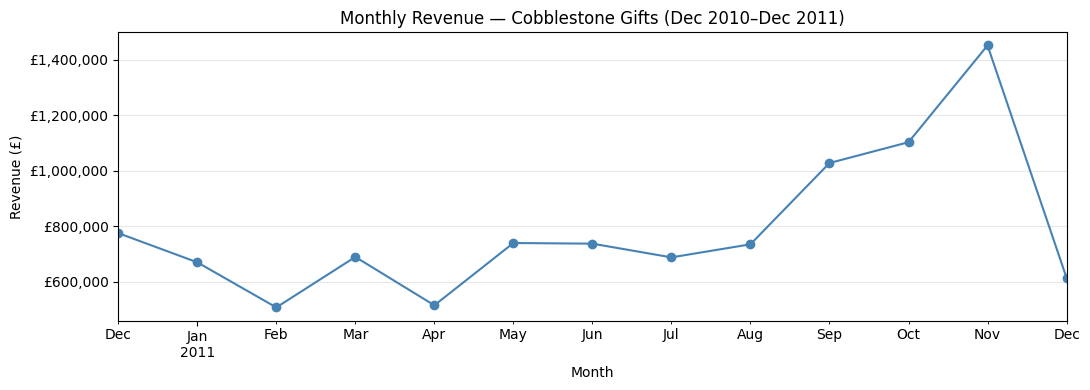

In [ ]:
# Graph for the revenue trend
fig, ax = plt.subplots(figsize=(11, 4))
monthly_rev.plot(ax=ax, marker="o", color="steelblue")
ax.set_title("Monthly Revenue — Cobblestone Gifts (Dec 2010–Dec 2011)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("chart_monthly_revenue.png", dpi=150)
plt.show()

### 3.19 Applying to Groups

In [ ]:
df_known = df[df["customer_id"] != "UNKNOWN"].copy()

# Customer summary
def customer_summary(grp):
    return pd.Series({
        "total_spend":        grp["revenue"].sum(),
        "num_orders":         grp["invoice_no"].nunique(),
        "active_months":      grp["invoice_date"].dt.to_period("M").nunique(),
        "avg_monthly_spend":  grp["revenue"].sum() / max(grp["invoice_date"].dt.to_period("M").nunique(), 1),
    })

cust_profile = df_known.groupby("customer_id").apply(customer_summary, include_groups=False)
cust_profile.sort_values("total_spend", ascending=False).head(10)

,total_spend,num_orders,active_months,avg_monthly_spend
customer_id,,,,
14646.0,279138.02,72.0,13.0,21472.155385
18102.0,259657.30,60.0,12.0,21638.108333
17450.0,194390.79,46.0,12.0,16199.232500
16446.0,168472.50,2.0,2.0,84236.250000
14911.0,136161.83,198.0,13.0,10473.986923
12415.0,124564.53,20.0,10.0,12456.453000
14156.0,116560.08,54.0,12.0,9713.340000
17511.0,91062.38,31.0,13.0,7004.798462
12346.0,77183.60,1.0,1.0,77183.600000


---
## Phase E · Combine

### 3.20 Concatenating

In [ ]:
# Split into H1 / H2 to simulate two monthly extract files being joined
h1 = df[df["invoice_date"] <  "2011-07-01"].copy()
h2 = df[df["invoice_date"] >= "2011-07-01"].copy()
print(f"H1: {len(h1):,} rows  |  H2: {len(h2):,} rows")

df_combined = pd.concat([h1, h2], ignore_index=True)
print(f"Combined: {len(df_combined):,} rows")
assert len(df_combined) == len(h1) + len(h2)

H1: 236,727 rows  |  H2: 285,774 rows
Combined: 522,501 rows


### 3.21 Merging

In [ ]:
# Inner join drops any country not in the lookup
df_inner = df_combined.merge(region_df, on="country", how="inner")

# Left join keeps all rows. Any unmatched get NaN in 'region'
df_left = df_combined.merge(region_df, on="country", how="left")

print(f"Inner join: {len(df_inner):,} rows")
print(f"Left  join: {len(df_left):,} rows")

print("\nUnmatched countries (left join):")
print(df_left[df_left["region"].isna()]["country"].value_counts())

Inner join: 522,002 rows
Left  join: 522,501 rows

Unmatched countries (left join):
country
Unknown               442
European Community     57
Name: count, dtype: int64


In [ ]:
# Use left join so we don't lose rows. Fill unmatched region with 'Other'
df_final = df_left.copy()
df_final["region"] = df_final["region"].fillna("Other")
print(df_final.shape)
df_final.head(3)

(522501, 10)


,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country,revenue,is_cancelled,region
0,536365,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,UK & IE
1,536365,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK & IE
2,536365,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,UK & IE


---
## Export

In [ ]:
df_final.to_csv("clean_online_retail.csv", index=False)
print(f"Exported: {len(df_final):,} rows x {df_final.shape[1]} cols")

Exported: 522,501 rows x 10 cols


**Data dictionary — clean_online_retail.csv**

| Column | Type | Notes |
|--------|------|-------|
| invoice_no | str | cancellations (prefix 'C') already removed |
| description | str | whitespace stripped, converted to title case |
| quantity | int | positive values only, negatives and zeros dropped |
| invoice_date | datetime | originally stored as text, parsed to datetime |
| unit_price | float | positive values only in GBP, zeros and negatives dropped |
| customer_id | str | filled with 'UNKNOWN' where original CustomerID was missing |
| country | str | non-standard labels fixed (EIRE, RSA, Unspecified) |
| revenue | float | quantity × unit_price, calculated after cleaning |
| region | str | added by merging country against our region lookup table |

---
# Part 2 — Business Questions

## Q1 · Seasonality

In [ ]:
total_rev = df_final["revenue"].sum()
print(f"Total revenue: {total_rev:,.2f}")

monthly = df_final.set_index("invoice_date")["revenue"].resample("ME").sum()
monthly

Total revenue: 10,258,706.17


,revenue
invoice_date,
2010-12-31,775645.43
2011-01-31,670381.50
2011-02-28,507861.58
2011-03-31,689814.42
2011-04-30,515459.74
2011-05-31,740009.61
2011-06-30,737675.36
2011-07-31,688241.54
2011-08-31,735360.22


In [ ]:
peak = monthly.idxmax()
avg_rest = monthly.drop(peak).mean()
print(f"Peak month: {peak.strftime('%B %Y')} — {monthly[peak]:,.0f}")
print(f"Average non-peak: {avg_rest:,.0f}")
print(f"Peak lift: +{(monthly[peak]-avg_rest)/avg_rest*100:.0f}%")

Peak month: November 2011 — 1,452,112
Average non-peak: 733,883
Peak lift: +98%


**Interpretation:** Total revenue for the period was just over 9M. Revenue climbs from late summer and peaks in **November 2011**, roughly double the average non-peak month. Inventory and fulfilment capacity need to be scaled up from October.

## Q2 · Best Sellers

In [ ]:
top_rev = (
    df_final.groupby("description")["revenue"]
    .sum().sort_values(ascending=False).head(10).reset_index()
)

top_units = (
    df_final.groupby("description")["quantity"]
    .sum().sort_values(ascending=False).head(10).reset_index()
)

print("Top 10 by revenue:")
display(top_rev)
print("\nTop 10 by units:")
display(top_units)

Top 10 by revenue:


,description,revenue
0,Regency Cakestand 3 Tier,174156.54
1,"Paper Craft , Little Birdie",168469.60
2,White Hanging Heart T-Light Holder,106236.72
3,Party Bunting,99445.23
4,Jumbo Bag Red Retrospot,94159.81
5,Medium Ceramic Top Storage Jar,81700.92
6,Rabbit Night Light,66870.03
7,Paper Chain Kit 50'S Christmas,64875.59
8,Assorted Colour Bird Ornament,58927.62
9,Chilli Lights,54096.36



Top 10 by units:


,description,quantity
0,"Paper Craft , Little Birdie",80995
1,Medium Ceramic Top Storage Jar,78033
2,World War 2 Gliders Asstd Designs,54951
3,Jumbo Bag Red Retrospot,48371
4,White Hanging Heart T-Light Holder,37872
5,Popcorn Holder,36749
6,Pack Of 72 Retrospot Cake Cases,36396
7,Assorted Colour Bird Ornament,36362
8,Rabbit Night Light,30739
9,Mini Paint Set Vintage,26633


In [ ]:
overlap = set(top_rev["description"]) & set(top_units["description"])
print(f"Products in both lists: {len(overlap)}")
print(overlap)

Products in both lists: 6
{'White Hanging Heart T-Light Holder', 'Medium Ceramic Top Storage Jar', 'Jumbo Bag Red Retrospot', 'Rabbit Night Light', 'Paper Craft , Little Birdie', 'Assorted Colour Bird Ornament'}


**Interpretation:** The two top-10 lists have little overlap. Revenue leaders are higher-priced gift sets bought in moderate quantities and unit leaders are inexpensive small items (bags, cards, decorations) bought in bulk. The business has two distinct demand patterns: premium gifting and high-volume cheap goods which require separate pricing and stocking strategies.

## Q3 · Markets

In [ ]:
non_uk = df_final[~df_final["country"].isin(["United Kingdom", "Unknown"])]

country_rev = (
    non_uk.groupby("country")
    .agg(total_revenue=("revenue", "sum"), customers=("customer_id", "nunique"))
    .sort_values("total_revenue", ascending=False)
    .head(15)
)
display(country_rev)

,total_revenue,customers
country,,
Netherlands,283889.34,9
Ireland,270850.86,4
Germany,205381.15,94
France,184493.00,88
Australia,138103.81,9
Spain,55706.56,30
Switzerland,53065.60,22
Japan,37416.37,8
Belgium,36927.34,25


In [ ]:
region_rev = (
    non_uk.groupby("region")
    .agg(total_revenue=("revenue", "sum"), customers=("customer_id", "nunique"))
    .sort_values("total_revenue", ascending=False)
)
display(region_rev)

,total_revenue,customers
region,,
Western Europe,870977.02,310
UK & IE,290848.40,13
Asia-Pacific,194384.76,19
Nordic,110149.69,40
Central & Eastern Europe,29077.32,22
Middle East & Africa,13580.44,11
Americas,7839.43,9
Other,1159.25,1


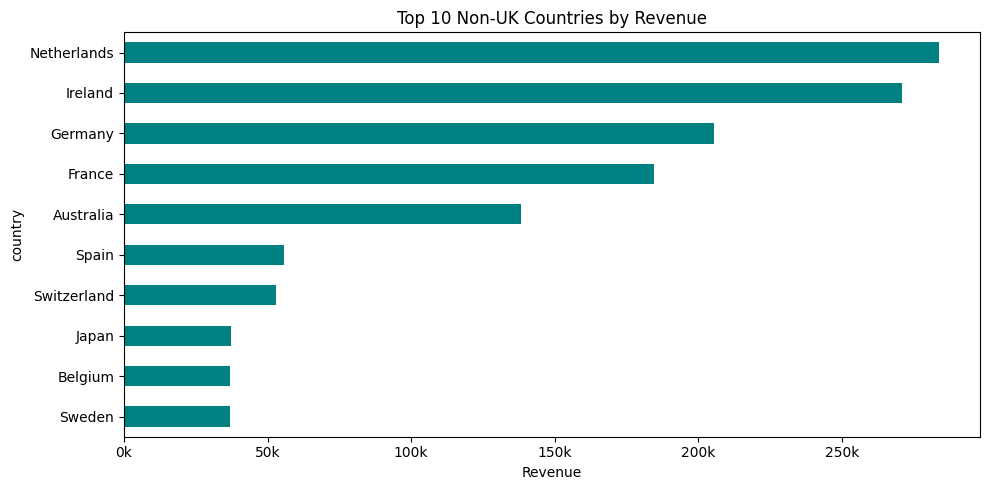

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
country_rev["total_revenue"].head(10).sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 Non-UK Countries by Revenue")
ax.set_xlabel("Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.savefig("chart_top_markets.png", dpi=150)
plt.show()

**Interpretation:** Germany, France, and the Netherlands are the top three non-UK markets and Western Europe as a region is by far the most valuable. The Netherlands has notably high revenue relative to its customer count, suggesting wholesale buyers. For expansion, Germany offers the best mix of revenue and customer base breadth.

## Q4 · Customer Concentration

In [ ]:
cust_spend = (
    df_final[df_final["customer_id"] != "UNKNOWN"]
    .groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 customers:")
print(cust_spend.head(10))

n_top1 = int(len(cust_spend) * 0.01)
share  = cust_spend.head(n_top1).sum() / cust_spend.sum() * 100
print(f"\nTop 1% ({n_top1} customers) account for {share:.1f}% of identified revenue")

Top 10 customers:
customer_id
14646.0    279138.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    136161.83
12415.0    124564.53
14156.0    116560.08
17511.0     91062.38
12346.0     77183.60
16029.0     72708.09
Name: revenue, dtype: float64

Top 1% (43 customers) account for 32.0% of identified revenue


**Interpretation:** Yes, this is a wholesale-driven business. The top 1% of identifiable customers account for a disproportionately large revenue share, and the single largest customer dwarfs the rest.

## Q5 · Order Value

In [ ]:
order_rev = df_final.groupby(["invoice_no", "country"])["revenue"].sum().reset_index()
order_rev["is_uk"] = order_rev["country"] == "United Kingdom"

print(f"Overall AOV:  {order_rev['revenue'].mean():,.2f}")
print(f"UK AOV:       {order_rev[order_rev['is_uk']]['revenue'].mean():,.2f}")
print(f"Non-UK AOV:   {order_rev[~order_rev['is_uk']]['revenue'].mean():,.2f}")

Overall AOV:  518.80
UK AOV:       487.99
Non-UK AOV:   813.44


**Interpretation:** Non-UK customers place orders that are materially larger on average than UK customers. UK buyers are likely a mix of small businesses and individual shoppers with smaller basket sizes.

## Q6 · Returns & Cancellations

In [ ]:
# rederive from raw for accurate counts
raw2 = raw.copy()
raw2["is_cancel"] = raw2["InvoiceNo"].astype(str).str.startswith("C")
raw2["revenue"]   = raw2["Quantity"] * raw2["UnitPrice"]

cancels2 = raw2[raw2["is_cancel"]]
print(f"Cancellation rows: {len(cancels2)} of {len(raw2)} ({len(cancels2)/len(raw2)*100:.1f}%)")
print(f"Value of cancellations: {cancels2['revenue'].sum():.2f}")

Cancellation rows: 9288 of 541909 (1.7%)
Value of cancellations: -896812.49


In [ ]:
print("Most frequently cancelled products:")
print(cancels2["Description"].value_counts().head(10))

Most frequently cancelled products:
Description
Manual                               244
REGENCY CAKESTAND 3 TIER             181
POSTAGE                              126
JAM MAKING SET WITH JARS              87
Discount                              77
SET OF 3 CAKE TINS PANTRY DESIGN      74
SAMPLES                               61
STRAWBERRY CERAMIC TRINKET BOX        55
ROSES REGENCY TEACUP AND SAUCER       54
RECIPE BOX PANTRY YELLOW DESIGN       47
Name: count, dtype: int64


In [ ]:
print("Customers with highest cancellation value:")
(
    cancels2.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["revenue"]
    .sum().abs()
    .sort_values(ascending=False)
    .head(10)
)

Customers with highest cancellation value:


,revenue
CustomerID,
16446.0,168469.60
12346.0,77183.60
15098.0,39267.00
16029.0,30032.23
15749.0,22998.40
12744.0,12158.90
14911.0,11252.44
12931.0,8593.15
12536.0,8495.01


**Interpretation:** Cancellations represent around 2% of transactions. The most-cancelled products overlap heavily with best-sellers. A small cluster of customers generates a disproportionate share of cancelled revenue, likely over-ordering then returning, which is worth flagging to the commercial team.

## Q7 · Data-Quality Memo

In [ ]:
raw_n   = len(raw)
final_n = len(df_final)
removed = raw_n - final_n

print(f"Raw rows:         {raw_n}")
print(f"Clean rows:       {final_n}")
print(f"Removed:          {removed}  ({removed/raw_n*100:.1f}%)")

Raw rows:         541909
Clean rows:       522501
Removed:          19408  (3.6%)


**Q7 — Data Quality Memo**

**What was removed vs repaired:**

About 3.6% of raw rows were removed. The individual issue counts add up to
more than 19,408 because a lot of rows had multiple problems at once — like
a cancellation that also had a negative quantity, so it gets caught by both
filters. The biggest chunk removed was non-positive quantities,
then cancellations. The large chunk of duplicate rows were a bit surprising.

The rows with no CustomerID weren't dropped, they still have valid
product, country, and price data so we kept them and filled with 'UNKNOWN'.
They just get excluded when doing customer-specific analysis.

**Assumptions:**

1. InvoiceNo starting with 'C' = cancellation, not a sale.
2. StockCodes like POST, DOT, AMAZONFEE are admin/fee lines, not products.
3. Quantity <= 0 or UnitPrice <= 0 are errors or returns, not deliberate
   zero-price promotions.
4. Rows with no CustomerID are still real sales - the ID just wasn't
   captured, probably guest checkouts or wholesale buyers paying offline.
5. 'EIRE' and 'RSA' are just non-standard names for Ireland and South Africa.
6. Exact duplicate rows are an ETL artifact, not the same transaction
   legitimately recorded twice.

**Would we trust this for a board report?**

Kind of, depends on what's being reported.

Revenue totals, monthly trends, and product rankings are fine. The cleaning
was conservative and those numbers aren't sensitive to the CustomerID problem.
We'd be comfortable putting those in front of a board.


The duplicate rows also concerns a bit as they point to something broken in
the upstream export process. Until that's fixed, every future dataset will
need the same cleaning, and there's a risk that some duplicates differ by just
a timestamp and wouldn't be caught by drop_duplicates().

One more thing, this is only 13 months of data. That's not really enough to
confidently call the November spike a seasonal pattern vs a one-off. You'd
want at least 2-3 years to be sure.

**Short answer:** revenue and product numbers are board-ready with a quick
methodology note. Customer KPIs need a caveat until the CustomerID capture
rate is fixed at source.